In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import warnings
warnings.filterwarnings('ignore')
 
from sklearn.model_selection import GroupKFold, cross_val_score, train_test_split
from sklearn.ensemble import ExtraTreesRegressor
from sklearn.preprocessing import RobustScaler
from sklearn.pipeline import Pipeline
from sklearn.base import BaseEstimator, RegressorMixin
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error
import xgboost as xgb

In [3]:
df = pd.read_csv('Merged_SoilMoisture_Data.csv')

In [4]:
df['Date'] = pd.to_datetime(df['Date'])
print(f"Loaded: {df.shape[0]} rows × {df.shape[1]} columns")
print(f"Points: {df['Point_ID'].nunique()}  |  Dates: {df['Date'].nunique()}")

Loaded: 401 rows × 17 columns
Points: 100  |  Dates: 22


In [17]:
def engineer_features(df):
    df = df.copy()
 
    #  Temporal features (captures seasonal SM cycle) 
    df['month']     = df['Date'].dt.month
    df['doy']       = df['Date'].dt.dayofyear
    df['month_sin'] = np.sin(2 * np.pi * df['month'] / 12)
    df['month_cos'] = np.cos(2 * np.pi * df['month'] / 12)
 
    #  Fix 3 missing SAR values (spatial median per point) 
    for col in ['VV_500m', 'VH_500m', 'Angle_500m']:
        null_mask = df[col].isnull()
        if null_mask.sum() > 0:
            fill = df.groupby('Point_ID')[col].transform('median')
            df.loc[null_mask, col] = fill[null_mask]
 
    #  SAR physics features 
    df['VV_linear']  = 10 ** (df['VV_500m'] / 10)   # dB → linear
    df['VH_linear']  = 10 ** (df['VH_500m'] / 10)
    df['VV_VH_diff'] = df['VV_500m'] - df['VH_500m']
 
    #  Terrain interaction features 
    df['slope_elev']  = df['Elevation_m'] / (df['Slope'] + 0.1)
    df['rough_slope'] = df['Roughness'] * df['Slope']
 
    df['VV_x_season'] = df['VV_linear'] * df['month_sin']
    df['VH_x_season'] = df['VH_linear'] * df['month_sin']
    df['VV_x_cos']    = df['VV_linear'] * df['month_cos']
    df['VH_x_cos']    = df['VH_linear'] * df['month_cos']
 
    return df
 
df = engineer_features(df)
 
FEATURES = [
    # SAR backscatter (raw + linear)
    'VV_500m', 'VH_500m', 'Angle_500m',
    'VV_linear', 'VH_linear', 'VV_VH_diff',
    # Polarimetric indices
    'CR=VH/VV', 'RVI', 'RPI=VV/VH', 'NDPI=(VV-VH)/(VV+VH)', 'MPI',
    # Terrain
    'Elevation_m', 'Slope', 'Aspect', 'Roughness',
    'slope_elev', 'rough_slope',
    # Temporal
    'doy','VV_x_season',
    'VH_x_season',
    'VV_x_cos',   
    'VH_x_cos'    
 
    
]

imp_features = ['doy',
 'VV_x_season',
 'Elevation_m',
 'slope_elev',
 'VH_x_season',
 'VH_x_cos',
 'VV_x_cos',
 'Angle_500m',
 'VV_500m',
 'Roughness']
 
#X = df[FEATURES].copy()
X = df[imp_features].copy()
y = df['Observed_SM'].copy()

In [18]:
unique_points = df['Point_ID'].unique()
np.random.seed(42)
test_points = np.random.choice(unique_points,
                                size=int(len(unique_points) * 0.2),
                                replace=False)
 
train_mask = ~df['Point_ID'].isin(test_points)
test_mask  =  df['Point_ID'].isin(test_points)
 
X_train, X_test = X[train_mask], X[test_mask]
y_train, y_test = y[train_mask], y[test_mask]
 
print(f"\nTrain: {X_train.shape[0]} rows  |  Test: {X_test.shape[0]} rows")
print(f"Test spatial points held out: {sorted(test_points)}")


Train: 323 rows  |  Test: 78 rows
Test spatial points held out: [np.int64(1), np.int64(7), np.int64(8), np.int64(11), np.int64(18), np.int64(27), np.int64(32), np.int64(38), np.int64(42), np.int64(46), np.int64(48), np.int64(53), np.int64(58), np.int64(79), np.int64(80), np.int64(83), np.int64(86), np.int64(92), np.int64(96), np.int64(100)]


In [19]:
scaler     = RobustScaler()
X_train_sc = scaler.fit_transform(X_train)
X_test_sc  = scaler.transform(X_test)

In [20]:
!pip install catboost

In [34]:
from catboost import CatBoostRegressor
from sklearn.preprocessing import RobustScaler
from sklearn.model_selection import GroupKFold, cross_val_score
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error
import numpy as np


gkf = GroupKFold(n_splits=5)
groups_train = df.loc[train_mask, 'Point_ID'].values

#  Best params found via manual grid search 
BEST_PARAMS = dict(
    iterations       = 500,
    learning_rate    = 0.03,
    depth            = 3,
    l2_leaf_reg      = 5,
    min_data_in_leaf = 8,
    random_seed      = 42,
    verbose          = 0
)

#  Train final model 
cb_model = CatBoostRegressor(**BEST_PARAMS)
cb_model.fit(X_train_sc, y_train)
def full_metrics(y_true, y_pred, label):
    r2     = r2_score(y_true, y_pred)
    rmse   = np.sqrt(mean_squared_error(y_true, y_pred))
    mae    = mean_absolute_error(y_true, y_pred)
    bias   = np.mean(y_pred - y_true)
    ubrmse = np.sqrt(np.mean(
        ((y_pred - y_pred.mean()) - (y_true - y_true.mean()))**2
    ))
    r = np.corrcoef(y_true, y_pred)[0, 1]
    print(f"\n{'─'*35}")
    print(f"  {label}")
    print(f"{'─'*35}")
    print(f"  R²     : {r2:.4f}")
    print(f"  R      : {r:.4f}")
    print(f"  RMSE   : {rmse:.4f} m³/m³")
    print(f"  ubRMSE : {ubrmse:.4f} m³/m³")
    print(f"  MAE    : {mae:.4f} m³/m³")
    print(f"  Bias   : {bias:.4f} m³/m³")
    return dict(r2=r2, r=r, rmse=rmse, ubrmse=ubrmse, mae=mae, bias=bias)


train_pred = cb_model.predict(X_train_sc)
test_pred  = cb_model.predict(X_test_sc)

train_m = full_metrics(y_train, train_pred, "TRAIN")
test_m  = full_metrics(y_test,  test_pred,  "TEST (spatial holdout)")

#  5-Fold Spatial CV 
print(f"\n{'─'*35}")
print(f"  5-FOLD SPATIAL CV")
print(f"{'─'*35}")

fold_r2, fold_rmse, fold_mae = [], [], []

for fold, (tr_idx, val_idx) in enumerate(
        gkf.split(X, y, groups=df['Point_ID']), 1):

    X_tr  = X.iloc[tr_idx].values
    X_val = X.iloc[val_idx].values
    y_tr  = y.iloc[tr_idx].values
    y_val = y.iloc[val_idx].values

    sc       = RobustScaler()
    X_tr_sc  = sc.fit_transform(X_tr)
    X_val_sc = sc.transform(X_val)

    fold_cb = CatBoostRegressor(**BEST_PARAMS)
    fold_cb.fit(X_tr_sc, y_tr)
    val_pred = fold_cb.predict(X_val_sc)

    f_r2   = r2_score(y_val, val_pred)
    f_rmse = np.sqrt(mean_squared_error(y_val, val_pred))
    f_mae  = mean_absolute_error(y_val, val_pred)

    fold_r2.append(f_r2)
    fold_rmse.append(f_rmse)
    fold_mae.append(f_mae)

    print(f"  Fold {fold}  →  R²={f_r2:.4f}  RMSE={f_rmse:.4f}  MAE={f_mae:.4f}")

print(f"{'─'*35}")
print(f"  Mean  →  R²={np.mean(fold_r2):.4f}  RMSE={np.mean(fold_rmse):.4f}  MAE={np.mean(fold_mae):.4f}")
print(f"  Std   →  R²={np.std(fold_r2):.4f}  RMSE={np.std(fold_rmse):.4f}  MAE={np.std(fold_mae):.4f}")

#  Feature Importance 
imp = pd.Series(cb_model.get_feature_importance(),
                index=imp_features).sort_values(ascending=False)
print("\nTop 10 Feature Importances:")
print(imp.head(10).round(4).to_string())


───────────────────────────────────
  TRAIN
───────────────────────────────────
  R²     : 0.6934
  R      : 0.8539
  RMSE   : 0.0448 m³/m³
  ubRMSE : 0.0448 m³/m³
  MAE    : 0.0355 m³/m³
  Bias   : -0.0003 m³/m³

───────────────────────────────────
  TEST (spatial holdout)
───────────────────────────────────
  R²     : 0.3807
  R      : 0.6173
  RMSE   : 0.0669 m³/m³
  ubRMSE : 0.0669 m³/m³
  MAE    : 0.0521 m³/m³
  Bias   : -0.0012 m³/m³

───────────────────────────────────
  5-FOLD SPATIAL CV
───────────────────────────────────
  Fold 1  →  R²=0.4433  RMSE=0.0540  MAE=0.0435
  Fold 2  →  R²=0.5793  RMSE=0.0475  MAE=0.0378
  Fold 3  →  R²=0.0960  RMSE=0.0756  MAE=0.0607
  Fold 4  →  R²=0.3370  RMSE=0.0784  MAE=0.0647
  Fold 5  →  R²=0.3131  RMSE=0.0696  MAE=0.0505
───────────────────────────────────
  Mean  →  R²=0.3538  RMSE=0.0650  MAE=0.0514
  Std   →  R²=0.1595  RMSE=0.0122  MAE=0.0101

Top 10 Feature Importances:
doy            19.1221
VH_x_cos       13.8944
Elevation_m    11.3

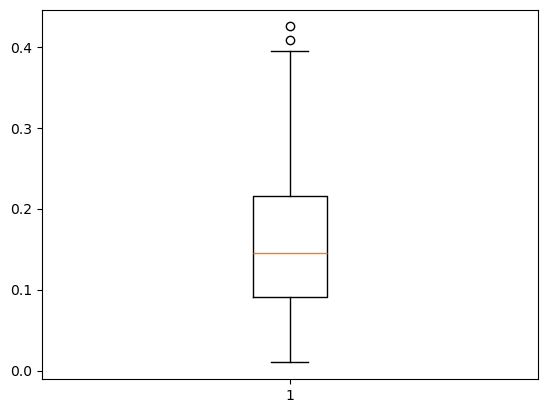

count    401.000000
mean       0.157953
std        0.081810
min        0.010000
5%         0.044000
25%        0.091000
50%        0.145000
75%        0.216000
95%        0.301000
99%        0.360000
max        0.425000
Name: Observed_SM, dtype: float64


In [12]:
import matplotlib.pyplot as plt
plt.boxplot(y)
plt.show()
print(df['Observed_SM'].describe(percentiles=[.05,.25,.75,.95,.99]))

In [13]:
corr = X.corr().abs()
high_corr = [(c1, c2, corr.loc[c1,c2]) 
             for c1 in corr.columns 
             for c2 in corr.columns 
             if c1 < c2 and corr.loc[c1,c2] > 0.90]
print(sorted(high_corr, key=lambda x: -x[2]))

[('NDPI=(VV-VH)/(VV+VH)', 'RVI', np.float64(0.9999999999999994)), ('VV_500m', 'VV_linear', np.float64(0.9815550307934747)), ('VH_500m', 'VH_linear', np.float64(0.9760479182058533)), ('Roughness', 'Slope', np.float64(0.9715059918300213)), ('VH_x_season', 'VV_x_season', np.float64(0.9708400935129615)), ('RPI=VV/VH', 'VV_VH_diff', np.float64(0.9677779813166896)), ('VH_x_cos', 'VV_x_cos', np.float64(0.9634238247437507)), ('Slope', 'rough_slope', np.float64(0.94735843560314)), ('Roughness', 'rough_slope', np.float64(0.9471402383304257))]


In [18]:
imp.head(10).index.tolist()

['doy',
 'VV_x_season',
 'Elevation_m',
 'slope_elev',
 'VH_x_season',
 'VH_x_cos',
 'VV_x_cos',
 'Angle_500m',
 'VV_500m',
 'Roughness']